In [1]:
from imagegrains import data_loader, grainsizing, plotting, gsd_uncertainty
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

>> Initializing ImageGrains with CellposeSAM:


Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.4 
platform:       	win32 
python version: 	3.10.18 
torch version:  	2.7.1+cu128! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




## Download pre-trained models and demo data  
If you have not donwloaded the pre-trained models and demo data yet from github, please see notebook **1_image_segmentation**. If you want to run on your own data, you can set the path manually in the next cell.

In [2]:
data_path = Path('F:/demo/debug')

This notebook will try to use segementation results from **1_image_segmentation** and the measured grain sizes from **2_grain_sizes**.

In [3]:
download_path = Path.home().joinpath('imagegrains')
data_path = download_path.joinpath('demo_data','FH').as_posix()

## Load the scaled results

In [4]:
#find results in folder for 'fh_pred'
fh_pred_gsds = data_loader.load_grain_set(data_path,gsd_str='pred_grains_re_scaled')
#find results in folder for label masks
gt_mask_gsds = data_loader.load_grain_set(data_path,gsd_str='mask_grains_re_scaled')

## Calculate the grain size disdtributions (GSD)

In [5]:
#specify column name for axis
column_name='ell: b-axis (mm)'
#load results and get gsd for each image for a specific axis column
fh_gsd_l,fh_id_l = grainsizing.gsd_for_set(fh_pred_gsds,column=column_name)
#do the same for label masks
gt_gsd_l,gt_id_l = grainsizing.gsd_for_set(gt_mask_gsds,column=column_name)

### Plot the GSDs

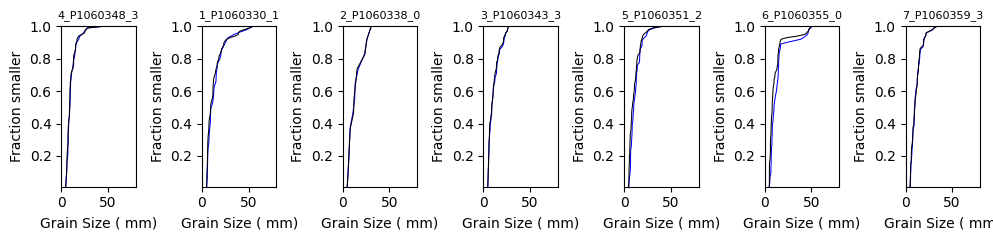

In [6]:
plt.figure(figsize=(10,2.5))
for i in range(len(fh_gsd_l)):
    plt.subplot(1,len(fh_gsd_l),i+1)
    plotting.plot_gsd(fh_gsd_l[i],color='b',length_max=80,orientation='vertical',label_axes=True,units= 'mm')
    plotting.plot_gsd(gt_gsd_l[i],color='k',length_max=80,orientation='vertical',label_axes=True,units= 'mm',title=fh_id_l[i].split('_full_set_cp_SAM_pred')[0])

## Calculate percentile uncertainties

In [7]:
#number of iterations for randomization
num_it  = 1000

In [ ]:
# Percentile uncertainty with bootstrapping (counting statistics only)
res_dict_bs = gsd_uncertainty.dataset_uncertainty(gsds=fh_pred_gsds,num_it=num_it,mute=True,column_name=column_name,return_results=True,sep=',',gsd_id = fh_id_l,tar_dir= data_path)
# Percentile uncertainty with Monte Carlo (counting statistics & scale, length uncertainty)
res_dict_MC = gsd_uncertainty.dataset_uncertainty(fh_pred_gsds,num_it=num_it,mute=True,column_name=column_name,method='MC',return_results=True,sep=',',gsd_id = fh_id_l,tar_dir= data_path)

ell: b-axis (mm) MC:   0%|          | 0/7 [00:00<?, ?gsd/s]

In [ ]:
# Estimate uncertainty for ground truth 
res_dict_gt_bs = gsd_uncertainty.dataset_uncertainty(gsds=gt_mask_gsds,num_it=num_it,mute=True,column_name=column_name,return_results=True,sep=',',gsd_id = gt_id_l, tar_dir= data_path)
res_dict_gt_MC = gsd_uncertainty.dataset_uncertainty(gsds=gt_mask_gsds,num_it=num_it,mute=True,column_name=column_name,method='MC',return_results=True,sep=',',gsd_id = gt_id_l, tar_dir= data_path)

ell: b-axis (mm) MC: 100%|██████████| 7/7 [01:49<00:00, 15.59s/gsd]


### Compare uncertainty methods

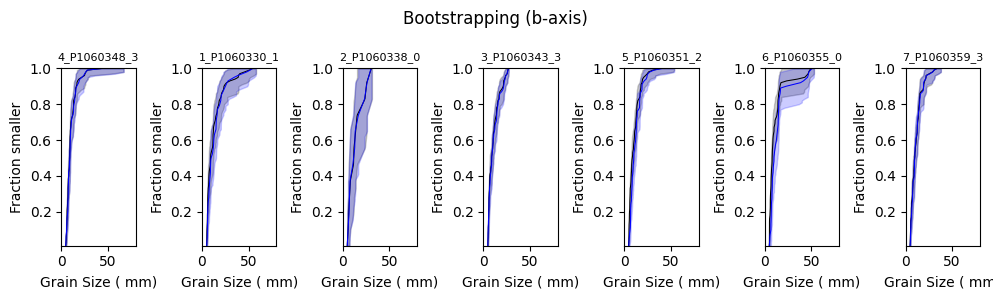

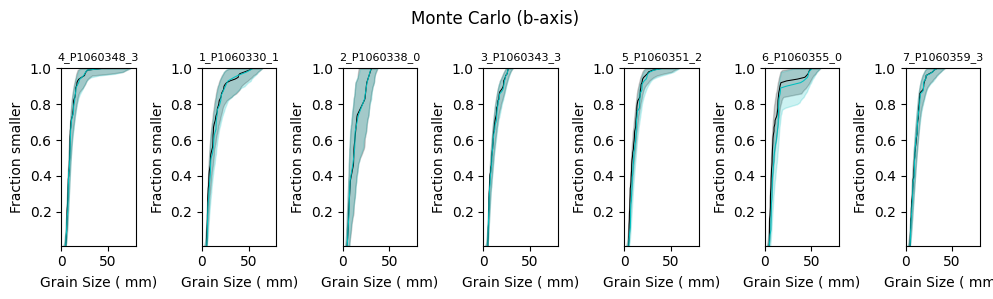

In [ ]:
plt.figure(figsize=(10,3))
for i in range(len(fh_gsd_l)):
    plt.subplot(1,len(fh_gsd_l),i+1)
    #plot gt gsd for reference
    plotting.plot_gsd(gt_gsd_l[i],color='k',length_max=80,orientation='vertical',label_axes=True,units= 'mm',title=fh_id_l[i].split('_full_set_cp_SAM_pred')[0])
    #plot gt uncertainty for reference
    plotting.plot_gsd_uncert(res_dict_gt_bs[gt_id_l[i]],color='k')
    #plot gsd
    plotting.plot_gsd(fh_gsd_l[i],color='b',length_max=80,orientation='vertical',label_axes=True,units= 'mm')
    #plot uncertainty
    plotting.plot_gsd_uncert(res_dict_bs[fh_id_l[i]],color='b')
    plt.suptitle('Bootstrapping (b-axis)')

plt.figure(figsize=(10,3))
for i in range(len(fh_gsd_l)):
    plt.subplot(1,len(fh_gsd_l),i+1)
    #plot gt gsd for reference
    plotting.plot_gsd(gt_gsd_l[i],color='k',length_max=80,orientation='vertical',label_axes=True,units= 'mm',title=fh_id_l[i].split('_full_set_cp_SAM_pred')[0])
    #plot gt uncertainty for reference
    plotting.plot_gsd_uncert(res_dict_gt_MC[gt_id_l[i]],color='k')
    #plot gsd
    plotting.plot_gsd(fh_gsd_l[i],color='c',length_max=80,orientation='vertical',label_axes=True,units= 'mm')
    #plot uncertainty
    plotting.plot_gsd_uncert(res_dict_MC[fh_id_l[i]],color='c')
    plt.suptitle('Monte Carlo (b-axis)')

## Calculate grain size statistics for each image

In [ ]:
summary_df = grainsizing.summary_statistics(fh_pred_gsds,fh_id_l,res_dict=res_dict_bs,data_id='fh_demo',save_summary=True)
summary_df

,Image/Masks,number of grains,D16,CI D16 (95%),D50,CI D50 (95%),D84,CI D84 (95%),D96,CI D96 (95%),unit,axis,method,grain approximation
0,4_P1060348_3_full_set_cp_SAM_pred_grains_re_sc...,57,15.7,[5.6 7.2],23.6,[ 7.8 10. ],38.3,[12.6 19.7],64.4,[15.6 57.7],mm,b-axis,bootstrapping,ellipse
1,1_P1060330_1_full_set_cp_SAM_pred_grains_re_sc...,38,15.4,[5.7 7.5],26.7,[ 8.1 15.1],53.3,[15.3 36.6],111.1,[23. 57.8],mm,b-axis,bootstrapping,ellipse
2,2_P1060338_0_full_set_cp_SAM_pred_grains_re_sc...,12,16.5,[ 4.9 11. ],30.6,[ 7. 20.1],61.8,[13. 31.],73.9,[16.7 31. ],mm,b-axis,bootstrapping,ellipse
3,3_P1060343_3_full_set_cp_SAM_pred_grains_re_sc...,73,14.2,[5.1 6.1],23.2,[ 7.4 11. ],44.2,[14.6 22.2],65.3,[21.9 26.8],mm,b-axis,bootstrapping,ellipse
4,5_P1060351_2_full_set_cp_SAM_pred_grains_re_sc...,61,17.5,[6.3 7.8],26.6,[ 8.7 12.9],44.1,[14.1 20.9],65.7,[19.3 45.7],mm,b-axis,bootstrapping,ellipse
5,6_P1060355_0_full_set_cp_SAM_pred_grains_re_sc...,35,17.4,[5.5 7.7],25.3,[ 8. 13.6],41.0,[14.3 46.1],120.3,[16.1 52.7],mm,b-axis,bootstrapping,ellipse
6,7_P1060359_3_full_set_cp_SAM_pred_grains_re_sc...,60,15.8,[5.4 7.4],25.8,[ 9. 12.3],40.4,[13.7 20.8],67.4,[19.2 35.4],mm,b-axis,bootstrapping,ellipse
